In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_orders = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name='Данные')
df_clients = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name='Clients')
df_regions = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name='Region_dict')


In [ ]:
df_orders.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


In [ ]:
df_orders.isna().sum()

,0
id_order,0
id_client,588
amt_payment,2144
dtime_pay,2429


In [ ]:
df_orders = df_orders.dropna()

In [ ]:
df_orders.isna().sum()

,0
id_order,0
id_client,0
amt_payment,0
dtime_pay,0


In [ ]:
df_clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [ ]:
df_clients.isna().sum()

,0
id_client,0
dtime_ad,249
nflag_test,0
id_trading_point,0


In [ ]:
df_clients = df_clients.dropna()

In [ ]:
df_regions.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [ ]:
df_regions.isna().sum()

,0
id_trading_point,0
city,0


In [ ]:
points_per_city = df_regions.groupby('city')['id_trading_point'].nunique().sort_values(ascending=False).reset_index()
points_per_city.columns = ['Город', 'Количество торговых точек']
print("Таблица группировки торговых точек по городам:")
points_per_city

Таблица группировки торговых точек по городам:


,Город,Количество торговых точек
0,Москва,11
1,Санкт-Петербург,11
2,Казань,6
3,Новосибирск,6
4,Красноярск,5
5,Самара,4
6,Краснодар,4
7,Саратов,2
8,Сочи,2
9,Мурманск,2


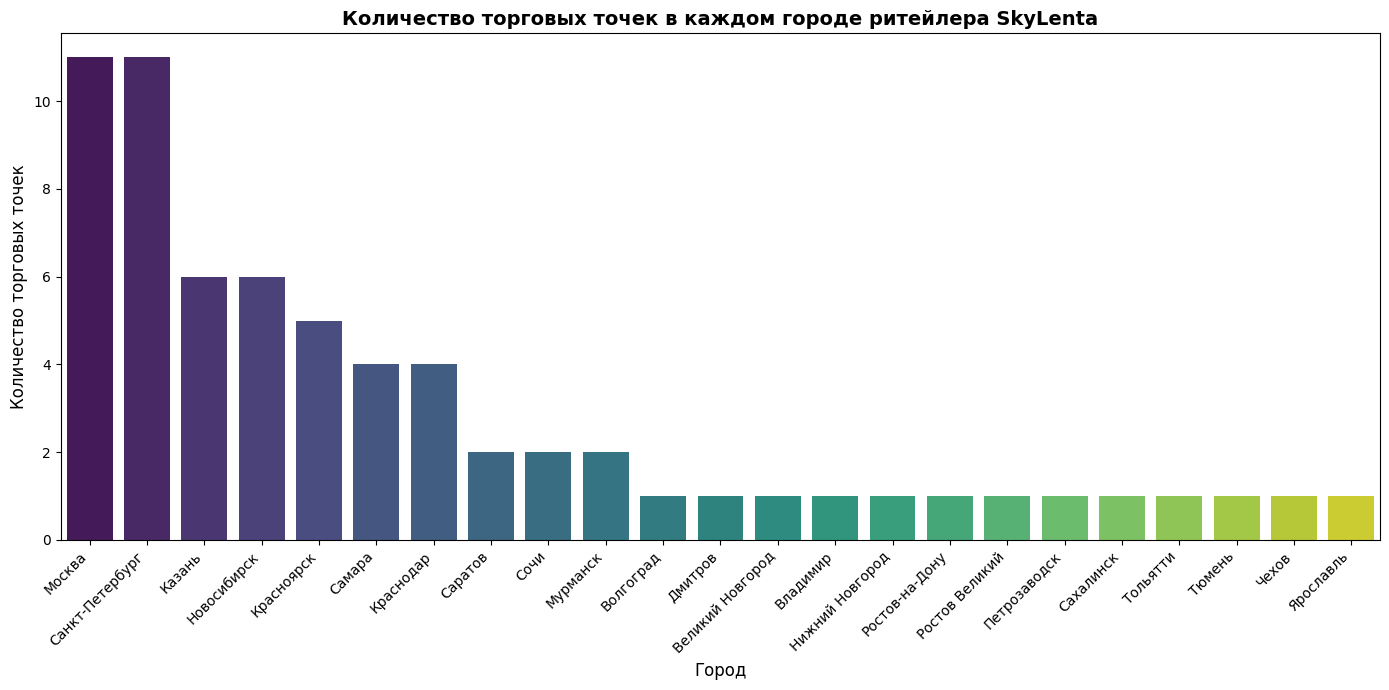

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(data=points_per_city, x='Город', y='Количество торговых точек', hue='Город', palette='viridis', legend=False)
plt.title('Количество торговых точек в каждом городе ритейлера SkyLenta', fontsize=14, fontweight='bold')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество торговых точек', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

На графике  мы видим, что торговая сеть ритейлера распределена по городам неравномерно. Ключевыми регионами присутствия компании являются Москва и Санкт-Петербург (по 11 магазинов). На втором месте по плотности сети идут Казань и Новосибирск (по 6 точек). В остальных городах представлено от 1 до 5 торговых точек. Такое распределение важно учитывать при последующей сегментации результатов A/B-теста, так как столичные регионы могут оказывать определяющее влияние на общие метрики за счёт своего масштаба.

In [ ]:
df_orders_gr = df_orders.groupby('id_client')['amt_payment'].sum().reset_index()
df_orders_gr.head()

,id_client,amt_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0


In [ ]:
df_merged = pd.merge(df_clients, df_orders_gr, on='id_client', how='left')
df_merged.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,226069,2022-07-11 16:28:38.511,1,54,NaN
2,183981,2022-06-16 12:23:59.289,1,991,6322.0
3,322530,2022-07-08 08:56:08.714,0,1015,NaN
4,254313,2022-06-19 22:18:01.770,1,453,NaN


In [ ]:
initial_clients_cnt = len(df_clients)
merged_clients_cnt = len(df_merged)

print(f"Количество клиентов в исходной таблице: {initial_clients_cnt}")
print(f"Количество клиентов после объединения: {merged_clients_cnt}")

Количество клиентов в исходной таблице: 55356
Количество клиентов после объединения: 55356


In [ ]:
df_merged['amt_payment'] = df_merged['amt_payment'].fillna(0)

In [ ]:
df_merged_all = pd.merge(df_merged, df_regions, on='id_trading_point', how='left')

In [ ]:
df_merged_all['flag_pay'] = (df_merged_all['amt_payment'] > 0).astype(int)

In [ ]:
print("Размер итоговой объединенной таблицы:", df_merged_all.shape)
print()
df_merged_all.head()

Размер итоговой объединенной таблицы: (55356, 7)



,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар,0
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0


In [ ]:
df_merged_all.isna().sum()

,0
id_client,0
dtime_ad,0
nflag_test,0
id_trading_point,0
amt_payment,0
city,0
flag_pay,0


In [ ]:
from scipy import stats

def test_calc(r1, r2, alpha=0.05):
    t_stat, p_value = stats.ttest_ind(r1, r2, equal_var=False)
    print(f"t-статистика: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < alpha:
        print("Результат: Разница статистически значима")
    else:
        print("Результат: Разница НЕ значима")
    return t_stat, p_value

In [ ]:
def mann_whitney_func(r1, r2, alpha=0.05):
    mw_stat, p_value = stats.mannwhitneyu(r1, r2, alternative='two-sided')
    print(f"MW-статистика: {mw_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < alpha:
        print("Результат: Разница статистически значима")
    else:
        print("Результат: Разница НЕ значима")
    return mw_stat, p_value

In [ ]:
all_points = df_merged_all['id_trading_point'].unique()

In [ ]:
zero_payment_points = []
for point in all_points:
    point_data = df_merged_all[df_merged_all['id_trading_point'] == point]
    test_sum = point_data[point_data['nflag_test'] == 1]['amt_payment'].sum()
    control_sum = point_data[point_data['nflag_test'] == 0]['amt_payment'].sum()

    if test_sum == 0 or control_sum == 0:
        zero_payment_points.append(int(point))

print("ID точек, в которых в тестовой или в контрольной группе выручка равна 0:")
print(zero_payment_points)

ID точек, в которых в тестовой или в контрольной группе выручка равна 0:
[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 23, 4, 1, 13]


In [ ]:
empty_group_points = []

for point in all_points:
    point_data = df_merged_all[df_merged_all['id_trading_point'] == point]
    test_cnt = len(point_data[point_data['nflag_test'] == 1])
    control_cnt = len(point_data[point_data['nflag_test'] == 0])

    if test_cnt == 0 or control_cnt == 0:
        empty_group_points.append(int(point))

print("ID точек, в которых пустует или контрольная, или тестовая группа:")
print(empty_group_points)

ID точек, в которых пустует или контрольная, или тестовая группа:
[1015, 866, 1099, 739, 228, 603, 810, 800]


In [ ]:
all_excluded_points = list(set(zero_payment_points + empty_group_points))
df_cleaned = df_merged_all[~df_merged_all['id_trading_point'].isin(all_excluded_points)]

print(f"Размер таблицы до чистки: {df_merged_all.shape}")
print(f"Размер таблицы после чистки: {df_cleaned.shape}")

Размер таблицы до чистки: (55356, 7)
Размер таблицы после чистки: (45318, 7)


Были исследованы две таргет-метрики: конверсия в платёж и чистый средний чек покупки. Посмотрим, изменились ли они в тестовой группе по сравнению с контрольной:

In [ ]:
conv_test = df_cleaned[df_cleaned['nflag_test'] == 1]['flag_pay'].mean() * 100
conv_control = df_cleaned[df_cleaned['nflag_test'] == 0]['flag_pay'].mean() * 100

print("Сравнение конверсии в платеж:")
print(f"Контрольная группа (Баннер): {conv_control:.2f}%")
print(f"Тестовая группа (Пуш): {conv_test:.2f}%")

ticket_test = df_cleaned[(df_cleaned['nflag_test'] == 1) & (df_cleaned['flag_pay'] == 1)]['amt_payment'].mean()
ticket_control = df_cleaned[(df_cleaned['nflag_test'] == 0) & (df_cleaned['flag_pay'] == 1)]['amt_payment'].mean()

print("\nСравнение чистого среднего чека:")
print(f"Контрольная группа (Баннер): {ticket_control:.2f} руб.")
print(f"Тестовая группа (Пуш): {ticket_test:.2f} руб.")


Сравнение конверсии в платеж:
Контрольная группа (Баннер): 49.98%
Тестовая группа (Пуш): 54.33%

Сравнение чистого среднего чека:
Контрольная группа (Баннер): 4380.48 руб.
Тестовая группа (Пуш): 4513.81 руб.


In [ ]:
print(f"Конверсия выросла на {conv_test - conv_control:.2f} процентных пункта")
print(f"Средний чек вырос на {ticket_test - ticket_control:.2f} руб.")

Конверсия выросла на 4.35 процентных пункта
Средний чек вырос на 133.32 руб.


Полученные метрики указывают на положительную динамику в тестовой группе. Чтобы определить, является ли зафиксированный прирост конверсии и среднего чека следствием внесенных изменений или же результатом случайных колебаний данных, проведём статистическое тестирование.

In [ ]:
pay_test = df_cleaned[(df_cleaned['nflag_test'] == 1) & (df_cleaned['flag_pay'] == 1)]['amt_payment']
pay_control = df_cleaned[(df_cleaned['nflag_test'] == 0) & (df_cleaned['flag_pay'] == 1)]['amt_payment']

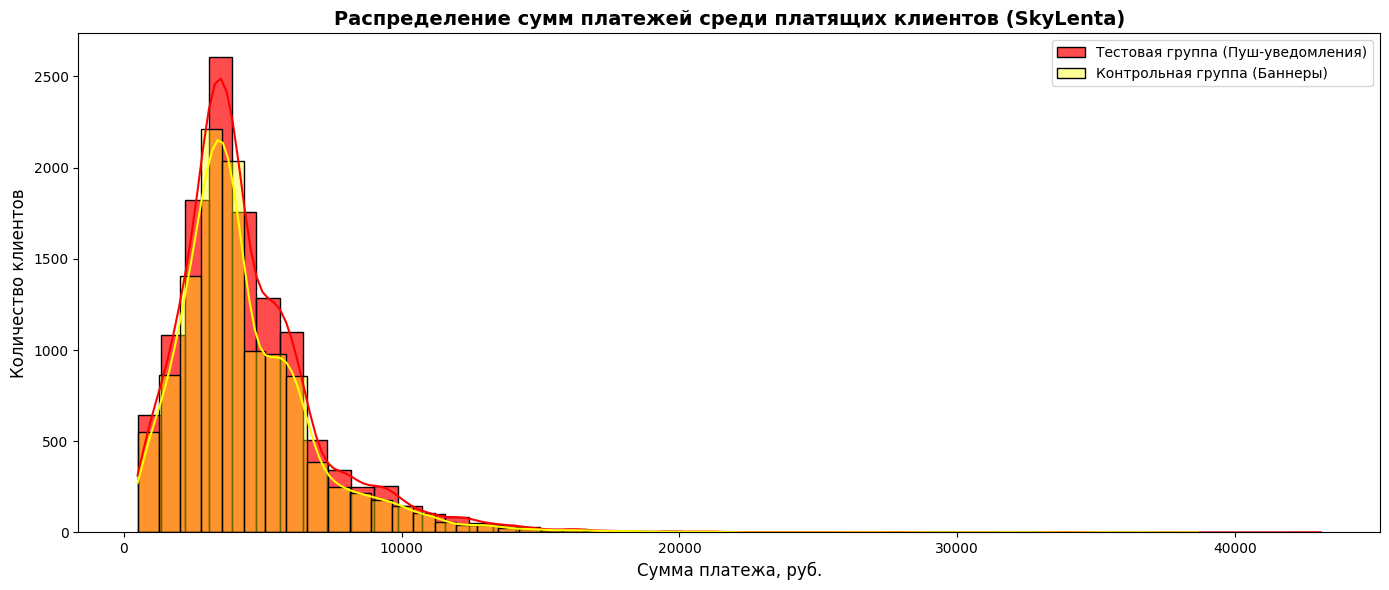

In [ ]:
plt.figure(figsize=(14, 6))
sns.histplot(pay_test, color='red', label='Тестовая группа (Пуш-уведомления)', kde=True, alpha=0.7, bins=50)
sns.histplot(pay_control, color='yellow', label='Контрольная группа (Баннеры)', kde=True, alpha=0.4, bins=50)

plt.title('Распределение сумм платежей среди платящих клиентов (SkyLenta)', fontsize=14, fontweight='bold')
plt.xlabel('Сумма платежа, руб.', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
active_test = df_cleaned[(df_cleaned['nflag_test'] == 1) & (df_cleaned['flag_pay'] == 1)]['amt_payment']
active_control = df_cleaned[(df_cleaned['nflag_test'] == 0) & (df_cleaned['flag_pay'] == 1)]['amt_payment']

In [ ]:
all_test_payments = df_cleaned[df_cleaned['nflag_test'] == 1]['amt_payment']
all_control_payments = df_cleaned[df_cleaned['nflag_test'] == 0]['amt_payment']

In [ ]:
test_conversion = df_cleaned[df_cleaned['nflag_test'] == 1]['flag_pay']
control_conversion = df_cleaned[df_cleaned['nflag_test'] == 0]['flag_pay']

In [ ]:
print("Сравнение средних чеков(Платящие клиенты)")
test_calc(active_test, active_control)

Сравнение средних чеков(Платящие клиенты)
t-статистика: 3.7757
p-value: 0.0002
Результат: Разница статистически значима


(np.float64(3.7757491472516005), np.float64(0.00015991845111898683))

Разница статистически значима. Новая механика (пуш-уведомления) оказала значимое влияние на сумму среднего чека платящих клиентов ритейлера SkyLenta.

In [ ]:
print("Сравнение конверсии в платёж")
test_calc(test_conversion, control_conversion)

Сравнение конверсии в платёж
t-статистика: 9.2824
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(9.282362400356973), np.float64(1.7284765137365216e-20))

Разница статистически значима. Пуш-уведомления продемонстрировали математически подтвержденное изменение конверсии по сравнению с базовыми баннерами.

In [ ]:
print("Сравнение распределений (Тест Манна-Уитни)")
mann_whitney_func(all_test_payments, all_control_payments)

Сравнение распределений (Тест Манна-Уитни)
MW-статистика: 270040116.0000
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(270040116.0), np.float64(3.008345273971901e-24))

Разница статистически значима. p-value близко к нулю, что подтверждает сдвиг общего распределения бюджетов покупателей в тестовой группе.

Сегментируем по городам:

In [ ]:
msk_test_pay = df_cleaned[(df_cleaned['city'] == 'Москва') & (df_cleaned['nflag_test'] == 1) & (df_cleaned['flag_pay'] == 1)]['amt_payment']
msk_control_pay = df_cleaned[(df_cleaned['city'] == 'Москва') & (df_cleaned['nflag_test'] == 0) & (df_cleaned['flag_pay'] == 1)]['amt_payment']

print("Москва: сравнение средних чеков")
test_calc(msk_test_pay, msk_control_pay)

Москва: сравнение средних чеков
t-статистика: 4.5758
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(4.57579863051099), np.float64(4.8342272638489825e-06))

In [ ]:
msk_test_conv = df_cleaned[(df_cleaned['city'] == 'Москва') & (df_cleaned['nflag_test'] == 1)]['flag_pay']
msk_control_conv = df_cleaned[(df_cleaned['city'] == 'Москва') & (df_cleaned['nflag_test'] == 0)]['flag_pay']

print("Москва: сравнение конверсии")
test_calc(msk_test_conv, msk_control_conv)

Москва: сравнение конверсии
t-статистика: 6.1905
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(6.19047063650437), np.float64(6.18851179009111e-10))

In [ ]:
msk_test_all = df_cleaned[(df_cleaned['city'] == 'Москва') & (df_cleaned['nflag_test'] == 1)]['amt_payment']
msk_control_all = df_cleaned[(df_cleaned['city'] == 'Москва') & (df_cleaned['nflag_test'] == 0)]['amt_payment']

print("Москва: сравнение распределений (Тест Манна-Уитни)")
mann_whitney_func(msk_test_all, msk_control_all)

Москва: сравнение распределений (Тест Манна-Уитни)
MW-статистика: 20595574.5000
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(20595574.5), np.float64(7.010591402203484e-16))

Разница в средних чеках и конверсии статистически значима. Внедрение пуш-уведомлений в Москве привело к математически подтвержденному росту как среднего чека платящих клиентов, так и общей конверсии в платеж.

In [ ]:
spb_test_pay = df_cleaned[(df_cleaned['city'] == 'Санкт-Петербург') & (df_cleaned['nflag_test'] == 1) & (df_cleaned['flag_pay'] == 1)]['amt_payment']
spb_control_pay = df_cleaned[(df_cleaned['city'] == 'Санкт-Петербург') & (df_cleaned['nflag_test'] == 0) & (df_cleaned['flag_pay'] == 1)]['amt_payment']

print("Санкт-Петербург: сравнение средних чеков")
test_calc(spb_test_pay, spb_control_pay)

Санкт-Петербург: сравнение средних чеков
t-статистика: 2.3074
p-value: 0.0211
Результат: Разница статистически значима


(np.float64(2.3073909315103713), np.float64(0.021079954622669834))

In [ ]:
spb_test_conv = df_cleaned[(df_cleaned['city'] == 'Санкт-Петербург') & (df_cleaned['nflag_test'] == 1)]['flag_pay']
spb_control_conv = df_cleaned[(df_cleaned['city'] == 'Санкт-Петербург') & (df_cleaned['nflag_test'] == 0)]['flag_pay']

print("Санкт-Петербург: сравнение конверсии")
test_calc(spb_test_conv, spb_control_conv)

Санкт-Петербург: сравнение конверсии
t-статистика: 9.3525
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(9.352479120817705), np.float64(1.0657220952695895e-20))

In [ ]:
spb_test_all = df_cleaned[(df_cleaned['city'] == 'Санкт-Петербург') & (df_cleaned['nflag_test'] == 1)]['amt_payment']
spb_control_all = df_cleaned[(df_cleaned['city'] == 'Санкт-Петербург') & (df_cleaned['nflag_test'] == 0)]['amt_payment']

print("Санкт-Петербург: сравнение распределений (Тест Манна-Уитни)")
mann_whitney_func(spb_test_all, spb_control_all)

Санкт-Петербург: сравнение распределений (Тест Манна-Уитни)
MW-статистика: 10899685.5000
p-value: 0.0000
Результат: Разница статистически значима


(np.float64(10899685.5), np.float64(2.0392184217953754e-20))

Разница в средних чеках и конверсии также статистически значима. В Санкт-Петербурге новая механика пуш-уведомлений продемонстрировала доказанную эффективность, значимо увеличив и средний чек, и конверсию покупателей по сравнению с контрольной группой.

In [ ]:
other_cities = [c for c in df_cleaned['city'].unique() if c not in ['Москва', 'Санкт-Петербург']]

for city in other_cities:
    city_data = df_cleaned[df_cleaned['city'] == city]

    test_pay = city_data[(city_data['nflag_test'] == 1) & (city_data['flag_pay'] == 1)]['amt_payment']
    control_pay = city_data[(city_data['nflag_test'] == 0) & (city_data['flag_pay'] == 1)]['amt_payment']

    test_conv = city_data[city_data['nflag_test'] == 1]['flag_pay']
    control_conv = city_data[city_data['nflag_test'] == 0]['flag_pay']

    test_all = city_data[city_data['nflag_test'] == 1]['amt_payment']
    control_all = city_data[city_data['nflag_test'] == 0]['amt_payment']

    if len(test_pay) > 1 and len(control_pay) > 1:
        print(f"Город: {city}")

        print("Сравнение средних чеков")
        test_calc(test_pay, control_pay)

        print("Сравнение конверсии")
        test_calc(test_conv, control_conv)

        print("Сравнение распределений (Манн-Уитни)")
        mann_whitney_func(test_all, control_all)
        print()

Город: Красноярск
Сравнение средних чеков
t-статистика: 0.5270
p-value: 0.5982
Результат: Разница НЕ значима
Сравнение конверсии
t-статистика: -0.2786
p-value: 0.7805
Результат: Разница НЕ значима
Сравнение распределений (Манн-Уитни)
MW-статистика: 4393882.0000
p-value: 0.8770
Результат: Разница НЕ значима

Город: Мурманск
Сравнение средних чеков
t-статистика: -1.0198
p-value: 0.3081
Результат: Разница НЕ значима
Сравнение конверсии
t-статистика: 0.8460
p-value: 0.3977
Результат: Разница НЕ значима
Сравнение распределений (Манн-Уитни)
MW-статистика: 569507.5000
p-value: 0.5434
Результат: Разница НЕ значима

Город: Казань
Сравнение средних чеков
t-статистика: 1.2117
p-value: 0.2258
Результат: Разница НЕ значима
Сравнение конверсии
t-статистика: 0.2730
p-value: 0.7848
Результат: Разница НЕ значима
Сравнение распределений (Манн-Уитни)
MW-статистика: 3263925.0000
p-value: 0.3773
Результат: Разница НЕ значима

Город: Саратов
Сравнение средних чеков
t-статистика: -0.9387
p-value: 0.3481
Резу

В большинстве исследованных городов (включая Красноярск, Мурманск, Казань, Саратов, Тольятти, Краснодар, Сахалинск, Дмитров) статистически значимых различий между группами не обнаружено ни по одной из метрик (p-value > 0.05). В этих локациях замена баннеров на пуш-уведомления не принесла измеримого маркетингового эффекта.

В Тюмени и Сочи пуш-уведомления значимо повлияли на рост конверсии (p-value = 0.0147 и 0.0473 соответственно), но не изменили средний чек.

В Волгограде и Владимире изменения зафиксированы только на уровне формы распределения или рангов по тесту Манна-Уитни (p-value = 0.0332 и 0.0317), в то время как средние показатели конверсии и чека значимо не изменились. Это указывает на то, что пуш-уведомления в данных городах повлияли лишь на отдельные сегменты покупателей (например, стимулировали к покупкам только определенные группы клиентов).

Самара стала единственным крупным региональным центром, где зафиксирован одновременный статистически значимый рост и конверсии, и среднего чека (p-value = 0.0000 для всех тестов).

**Рекомендация для бизнеса: Рекомендуется полноценное масштабное внедрение пуш-уведомлений в Москве, Санкт-Петербурге и Самаре. Для городов с точечным эффектом (Тюмень, Сочи, Волгоград, Владимир) целесообразно использовать гибридный подход или провести дополнительную сегментацию аудитории. В остальных регионах на текущем этапе экономически обосновано временно сохранить классические баннеры, так как пуш-сообщения не демонстрируют превосходства в эффективности.**

In [ ]:
df_report = pd.DataFrame()

In [ ]:
total_observations = len(df_cleaned)

In [ ]:
grouped = df_cleaned.groupby(['city', 'id_trading_point'])

In [ ]:
for (city, point_id), group in grouped:
    test_group = group[group['nflag_test'] == 1]
    control_group = group[group['nflag_test'] == 0]

    cnt_test = len(test_group)
    cnt_control = len(control_group)
    cnt_all = cnt_test + cnt_control
    percent_cnt = (cnt_all / total_observations) * 100

    payments_test = test_group['amt_payment']
    payments_control = control_group['amt_payment']

    avg_payment_test = payments_test.mean()
    avg_payment_control = payments_control.mean()
    diff = avg_payment_test - avg_payment_control

    sigma_test = payments_test.std(ddof=1) if cnt_test > 1 else 0
    sigma_control = payments_control.std(ddof=1) if cnt_control > 1 else 0

    if cnt_test > 1 and cnt_control > 1:
        t_stat, pvalue_ttest = stats.ttest_ind(payments_test, payments_control, equal_var=False)
    else:
        t_stat, pvalue_ttest = np.nan, np.nan

    alpha = 0.05
    if not np.isnan(pvalue_ttest) and pvalue_ttest < alpha:
        label = 'Положительный' if diff > 0 else 'Отрицательный'
    else:
        label = 'Нейтральный'

    row = pd.DataFrame([{
        'city': city,
        'id_trading_point': point_id,
        'count_test': cnt_test,
        'count_control': cnt_control,
        'count_all': cnt_all,
        'percent_count': percent_cnt,
        'avg_payment_test': avg_payment_test,
        'avg_payment_control': avg_payment_control,
        'diff': diff,
        'sigma_test': sigma_test,
        'sigma_control': sigma_control,
        'ttest': t_stat,
        'pvalue_ttest': pvalue_ttest,
        'result_label': label
    }])

    df_report = pd.concat([df_report, row], ignore_index=True)

print("Пустой датафрейм успешно создан и заполнен в цикле!")
df_report.head()

Пустой датафрейм успешно создан и заполнен в цикле!


,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,result_label
0,Владимир,11,509,608,1117,2.464804,2547.220039,2108.610197,438.609842,3023.702164,2663.038392,2.548235,0.010972,Положительный
1,Волгоград,66,657,703,1360,3.001015,2288.870624,2601.761024,-312.890400,2682.567610,2830.193773,-2.093060,0.036529,Отрицательный
2,Дмитров,2,78,71,149,0.328788,579.333333,483.450704,95.882629,1860.762430,1654.923182,0.332885,0.739696,Нейтральный
3,Казань,439,355,351,706,1.557880,2481.960563,2400.635328,81.325236,4040.441007,3722.117072,0.278197,0.780944,Нейтральный
4,Казань,477,382,386,768,1.694691,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.892096,0.372624,Нейтральный


In [ ]:
df_positive = df_report[df_report['result_label'] == 'Положительный']
df_negative = df_report[df_report['result_label'] == 'Отрицательный']
df_neutral = df_report[df_report['result_label'] == 'Нейтральный']

In [ ]:
with pd.ExcelWriter('ab_test_report.xlsx', engine='openpyxl') as writer:
    df_positive.to_excel(writer, sheet_name='Положительные исходы', index=False)
    df_negative.to_excel(writer, sheet_name='Отрицательные исходы', index=False)
    df_neutral.to_excel(writer, sheet_name='Нейтральные исходы', index=False)

print("Файл ab_test_report.xlsx успешно сохранен и готов к скачиванию!")

Файл ab_test_report.xlsx успешно сохранен и готов к скачиванию!


**Итоговое заключение после составления калькулятора**: На основе нашей финальной таблицы в Excel получились очень понятные цифры. Если мы запустим пуши на полную мощность на 10 000 покупателей, то чистыми компания заработает 2 380 195 рублей (и это уже с учётом того, что мы вычли 256 тысяч потерь в тех магазинах, где пуши не сработали).В итоге проект вышел суперприбыльным. Эту механику точно стоит полностью внедрять В Санкт-Петербурге, Москве и Самаре. По тем городам, где тест пока остался нейтральным, для получения полной картины в следующих исследованиях необходимо добрать ещё 8 298 заказов, чтобы накопить нормальную статистику и принять по ним окончательное решение.